# Bitcoin Price Prediction — Best Model Pipeline

## Business Context
Bitcoin (BTC) is the world's leading cryptocurrency and one of the most traded financial assets globally. Its price is driven by market sentiment, adoption trends, regulatory news, and macro-economic conditions. Accurate daily price prediction helps traders optimise entry/exit decisions, risk management systems automate exposure limits, and investment platforms provide data-driven recommendations.

This notebook implements a full end-to-end ML pipeline using **Random Forest** — selected as the best-performing model from our honest log-return evaluation study in `01-compare-models.ipynb`.

> **Why Random Forest won:** When all models are scored in log-return space against a persistence baseline (predict log-return = 0), Random Forest achieves the lowest RMSE and highest directional accuracy. The GRU's apparent advantage in price-space R² is an artefact of the lag-1 carry term, not genuine predictive skill.

Pipeline steps:
1. **Data retrieval** — historical Bitcoin/USD prices (`BTC-USD`) via Yahoo Finance (`yfinance`)
2. **EDA** — exploratory analysis and moving-average visualisations
3. **Feature engineering** — RSI(14), MACD(12,26,9), rolling std(30), 20-day lag window, log-returns (all leak-free)
4. **Preprocessing** — MinMaxScaler (features) + StandardScaler (log-return target)
5. **Modelling** — train Random Forest with MLflow experiment tracking
6. **Evaluation** — log-return RMSE, R², DirAcc% vs persistence baseline (honest metrics only)


## Setup

Install the project dependencies from `requirements.txt` and run this notebook in a virtual environment. Run from terminal:

```powershell
python -m pip install -r requirements.txt
```

In [1]:
# Imports
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
from IPython.display import display

import yfinance as yf
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import joblib
import os
import mlflow

# ── Shared color palette (consistent across all notebooks) ───────────────────
# purple / blue / gray family — no greens or reds
PALETTE = {
    'close':  '#6C5CE7',   # medium purple  — BTC raw close price line
    'actual': '#1E293B',   # very dark slate — actual prices in eval plots
    'rf':     '#3B82F6',   # strong blue    — RF model predictions
    'ma100':  '#818CF8',   # light indigo   — 100-day moving average
    'ma200':  '#C4B5FD',   # very light purple — 200-day moving average
    'pers':   '#94A3B8',   # medium gray    — persistence baseline
    'grid':   '#E4EAF2',   # grid lines
    'hl':     '#EEF2FF',   # area shading
}

# ── Global plot style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FB',
    'axes.edgecolor':    '#D0D7E3',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'grid.color':        PALETTE['grid'],
    'grid.linestyle':    '--',
    'grid.linewidth':    0.6,
    'axes.grid':         True,
    'font.size':         11,
})

print(f"MLflow: {mlflow.__version__}")


MLflow: 3.11.1


## Step 1 — Data Acquisition

Connect to Yahoo Finance and download daily Bitcoin/USD price data (`BTC-USD`) from 2015 to today.

In [2]:
# Parameters and data loader
START = '2015-01-01'
TODAY = date.today().strftime('%Y-%m-%d')
TICKER = 'BTC-USD'

def load_data(ticker, start=START, end=TODAY, interval='1d'):
    df = yf.download(ticker, start=start, end=end, interval=interval)
    # yfinance >= 0.2 returns MultiIndex columns for single tickers — flatten them
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.reset_index(inplace=True)
    # Ensure Close is a plain 1-D Series (not a DataFrame)
    df['Close'] = df['Close'].squeeze()
    return df

df = load_data(TICKER)
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,2015-01-01,314.248993,320.434998,314.002991,320.434998,8036550
1,2015-01-02,315.032013,315.838989,313.565002,314.079010,7860650
2,2015-01-03,281.082001,315.149994,281.082001,314.846008,33054400
3,2015-01-04,264.195007,287.230011,257.612000,281.145996,55629100
4,2015-01-05,274.473999,278.341003,265.084015,265.084015,43962800


In [3]:
# --- EDA ---
print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
df[['Open','High','Low','Close','Volume']].describe()

Shape: (4135, 6)

Column types:
Price
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object

Missing values:
Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Descriptive statistics:


Price,Open,High,Low,Close,Volume
count,4135.000000,4135.000000,4135.000000,4135.000000,4.135000e+03
mean,28894.865799,29471.846867,28282.873869,28912.457592,2.276079e+10
std,32356.507132,32904.624231,31767.309772,32361.566004,2.300274e+10
min,176.897003,211.731003,171.509995,178.102997,7.860650e+06
25%,3856.398926,3936.175049,3785.456299,3861.999390,2.981575e+09
50%,11931.991211,12335.707031,11681.480469,11959.371094,1.841390e+10
75%,46328.259766,47345.580078,44804.363281,46366.994141,3.473006e+10
max,124752.140625,126198.070312,123196.046875,124752.531250,3.509679e+11


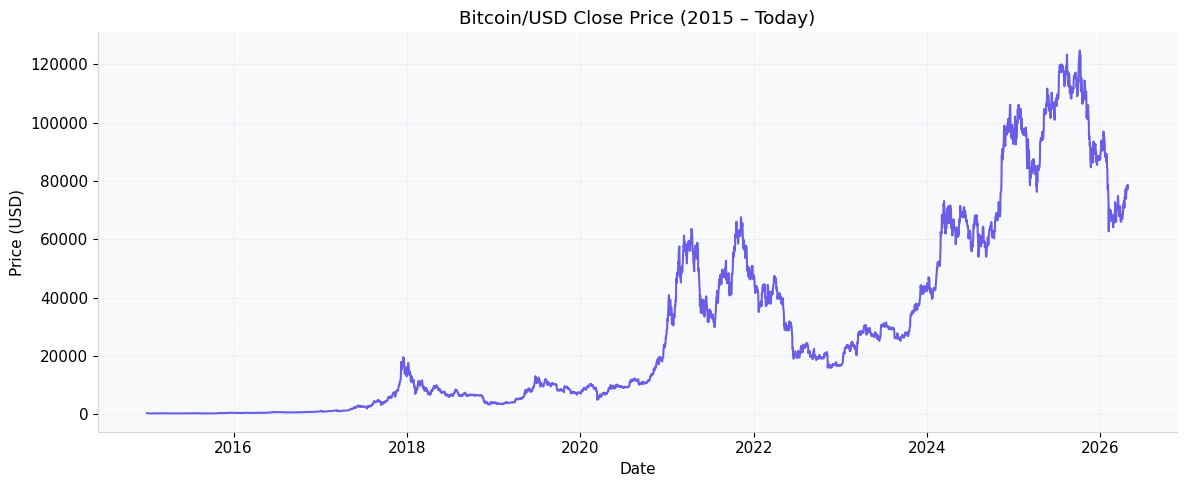

In [4]:
# Quick visualization of Close price
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], color=PALETTE['close'], linewidth=1.5)
plt.title('Bitcoin/USD Close Price (2015 – Today)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

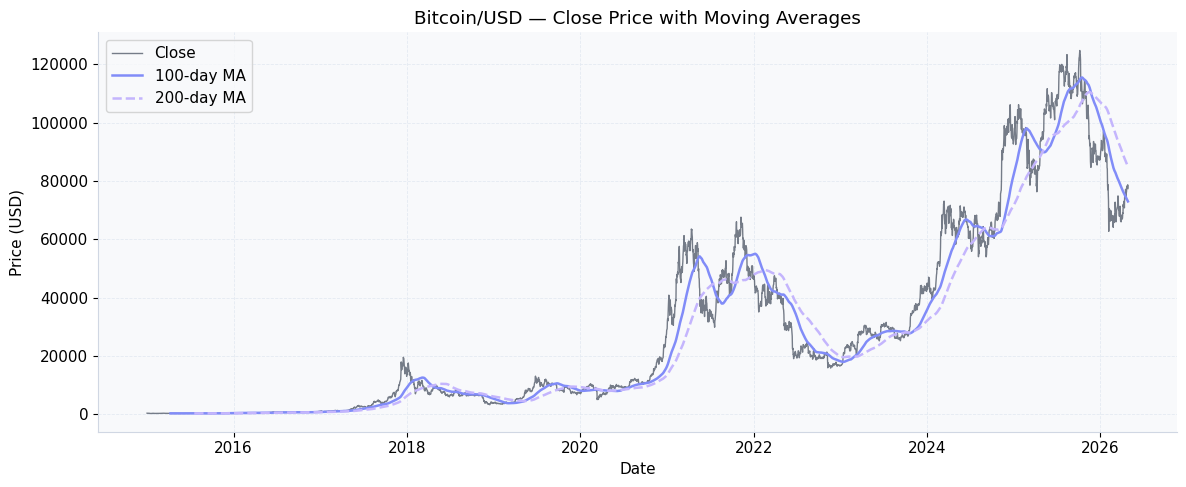

In [5]:
# Moving averages — 100 day and 200 day
ma100 = df['Close'].rolling(100).mean()
ma200 = df['Close'].rolling(200).mean()

plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['Close'], label='Close',       color=PALETTE['actual'], alpha=0.6, linewidth=1)
plt.plot(df['Date'], ma100,       label='100-day MA',  color=PALETTE['ma100'],  linewidth=1.8)
plt.plot(df['Date'], ma200,       label='200-day MA',  color=PALETTE['ma200'],  linewidth=1.8, linestyle='--')
plt.title('Bitcoin/USD — Close Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# ── Feature engineering helpers ───────────────────────────────────────
LOOKBACK = 20   # GRU sequence length (timesteps fed into the model)
SEQ_LEN  = LOOKBACK  # lag window length = LOOKBACK (GRU-only notebook)

def rsi(series: pd.Series, period: int = 14) -> pd.Series:
    delta = series.diff()
    up    = delta.clip(lower=0).rolling(period).mean()
    down  = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + up / down))

def macd_features(series: pd.Series, a=12, b=26, c=9):
    ema_a = series.ewm(span=a, adjust=False).mean()
    ema_b = series.ewm(span=b, adjust=False).mean()
    line  = ema_a - ema_b
    sig   = line.ewm(span=c, adjust=False).mean()
    return line, sig

def build_features(df: pd.DataFrame, seq_len: int = SEQ_LEN) -> pd.DataFrame:
    """Build a leak-free feature matrix from raw OHLCV data.

    WHY shift by 1?
    ---------------
    When predicting close[t], the model must only see information that was
    available *before* day t opened — i.e. up to and including close[t-1].
    Without .shift(1), an indicator computed from close[t] would leak future
    information into the feature for that same row, producing unrealistically
    good backtested metrics and a model that fails in live trading.

    Which features need shifting and why:
      • return, std30, rsi14, macd, macd_sig — all computed using a rolling
        or EMA window that includes close[t], so they must be shifted.
      • lag_1 … lag_20 — already reference close[t-1] … close[t-20] by
        construction, so they are inherently leak-free (no shift needed).
    """
    d = df[['Date', 'Close']].copy()

    # ── Indicators that include close[t] → shift so row t gets yesterday's value ──
    d["return"]   = d["Close"].pct_change().shift(1)       # yesterday's 1-day return
    d["std30"]    = d["Close"].rolling(30).std().shift(1)  # 30-day volatility as of yesterday
    d["rsi14"]    = rsi(d["Close"]).shift(1)               # RSI(14) as of yesterday
    ml, ms        = macd_features(d["Close"])
    d["macd"]     = ml.shift(1)                            # MACD line as of yesterday
    d["macd_sig"] = ms.shift(1)                            # MACD signal as of yesterday
    d = d.dropna().reset_index(drop=True)

    # ── Lag prices: lag_1 = close[t-1], lag_2 = close[t-2], …
    # Inherently leak-free — they reference past closes by definition. ──────────────
    for i in range(1, seq_len + 1):
        d[f"lag_{i}"] = d["Close"].shift(i)
    d = d.dropna().reset_index(drop=True)
    return d

print("Feature engineering helpers defined.")


Feature engineering helpers defined.


## Step 2 — Feature Engineering & Preprocessing

### Lookahead leakage — what it is and why it matters

**Lookahead leakage** occurs when a feature used to predict `close[t]` is computed using `close[t]` itself (or any later value). The model learns from information it could never have in a real trading scenario, producing metrics that look great in testing but fail completely in production.

**How we prevent it:** every indicator derived from the closing-price series is shifted forward by 1 day with `.shift(1)`. This means the value stored in row `t` reflects the indicator as it stood at the *end of day t-1* — exactly what a trader would know before day `t` opens.

| Feature | Computed from | `.shift(1)` applied? | Reason |
|---|---|---|---|
| `return` | `close[t]` via `pct_change()` | ✅ Yes | uses today's close |
| `std30` | rolling window ending at `close[t]` | ✅ Yes | window includes today |
| `rsi14` | rolling window ending at `close[t]` | ✅ Yes | window includes today |
| `macd` / `macd_sig` | EMA ending at `close[t]` | ✅ Yes | EMA includes today |
| `lag_1 … lag_20` | `close[t-1]` … `close[t-20]` | ❌ No — already safe | reference past closes by definition |

### Other preprocessing choices

- **Target:** log-return `log(close[t] / close[t-1])` — stationary and avoids price-range extrapolation issues with tree models
- **MinMaxScaler** on features (X); **StandardScaler** on log-return target (y — can be negative, so MinMax is inappropriate)
- **Train/test split: 70% / 30%** — chronological, no shuffling (shuffling would cause leakage across the split boundary)
- **GRU sequences:** `LOOKBACK = 20` timesteps of scaled lag prices fed in oldest → newest order


In [7]:
# ── Build features & prepare train/test splits ────────────────────────
feat_df = build_features(df, seq_len=SEQ_LEN)

lag_cols     = [f"lag_{i}" for i in range(1, SEQ_LEN + 1)]
extra_cols   = ["std30", "rsi14", "macd", "macd_sig", "return"]
feature_cols = lag_cols + extra_cols

X      = feat_df[feature_cols].copy()
dates  = feat_df["Date"].copy()

# Target: log-return (stationary — avoids price-range extrapolation)
y = np.log(feat_df["Close"] / feat_df["lag_1"])

split = int(len(X) * 0.70)
X_train, X_test = X.iloc[:split],  X.iloc[split:]
y_train, y_test = y.iloc[:split],  y.iloc[split:]
dates_test = dates.iloc[split:].reset_index(drop=True)

# Kept for price reconstruction during evaluation
close_test_actual = feat_df["Close"].iloc[split:].values
close_prev_test   = X_test["lag_1"].values

# Scale features (fit on train only)
scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_s  = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Total samples: {len(X)} | Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Features: {len(feature_cols)}  (lag×{SEQ_LEN} + 5 indicators, all leak-free)")


Total samples: 4085 | Train: 2859 | Test: 1226
Features: 25  (lag×20 + 5 indicators, all leak-free)


## Step 3 — Train Best Model (Random Forest)

**Random Forest** was selected as the best model from `01-compare-models.ipynb` based on log-return RMSE against the persistence baseline — the honest skill metric.

Random Forest trains on the full flat feature vector (20 lags + 5 technical indicators) and predicts the next-day log-return directly. No sequences are needed.

Each training run is logged in MLflow under the **`bitcoin-price-prediction`** experiment.


In [8]:
# ── Train Random Forest ───────────────────────────────────────────────
REPO_ROOT  = os.path.dirname(os.getcwd())
MLFLOW_DIR = os.path.join(REPO_ROOT, 'mlflow')
MODELS_DIR = os.path.join(REPO_ROOT, 'models')
os.makedirs(MLFLOW_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{os.path.join(MLFLOW_DIR, 'mlflow.db')}")
mlflow.set_experiment("bitcoin-price-prediction")

RF_N_ESTIMATORS = 300
RF_MAX_DEPTH    = None   # unlimited — early experiments showed no overfitting benefit from capping

rf_model = RandomForestRegressor(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=42,
    n_jobs=-1,
)

with mlflow.start_run(run_name="rf-btc-usd"):
    mlflow.log_param("model",         "RandomForest")
    mlflow.log_param("ticker",        "BTC-USD")
    mlflow.log_param("n_estimators",  RF_N_ESTIMATORS)
    mlflow.log_param("max_depth",     str(RF_MAX_DEPTH))
    mlflow.log_param("seq_len",       SEQ_LEN)
    mlflow.log_param("train_size",    len(X_train_s))
    mlflow.log_param("test_size",     len(X_test_s))

    rf_model.fit(X_train_s, y_train_s)

print("Random Forest training complete.")
print(f"  n_estimators: {RF_N_ESTIMATORS}  |  features: {len(feature_cols)}")


Random Forest training complete.
  n_estimators: 300  |  features: 25


## Step 4 — Evaluate, Save & Plot

Evaluate the GRU on the held-out 30% test set, log metrics to MLflow, save model artifacts, and visualise predictions.

Metrics are reported in **log-return space** — the space the model was trained in and the only honest measure of skill:

| Metric | Description |
|--------|-------------|
| **Log-return RMSE** | Error in the model’s actual output space (lower = better) |
| **Log-return R²** | Proportion of log-return variance explained (R² = 0 means no skill beyond predicting the mean) |
| **DirAcc %** | % of days the predicted direction (up/down) was correct (> 50% = better than coin flip) |
| **Persistence RMSE (ref)** | Price RMSE for the do-nothing baseline (predicted price = previous close) |

> Price-space R² is not reported: ~99% of a predicted price comes from `close[t-1]`, not the model output, making it artifically inflated for any model.


,Log-ret RMSE,Log-ret R²,DirAcc %,Price RMSE (ref)
Model,,,,
Random Forest,0.02787,-0.2747,51.71,"$1,918"
Persistence,0.02472,0.0000,NaN,"$1,717"



RF log-return R²: -0.2747  |  DirAcc: 51.7%
Price RMSE for reference: RF $1,918  vs Persistence $1,717

Model saved      -> c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models\rf_model.save
selection.json   -> c:\Users\User\Desktop\Ironhack-DS-AI\capstone-ml-on-cloud\models\selection.json


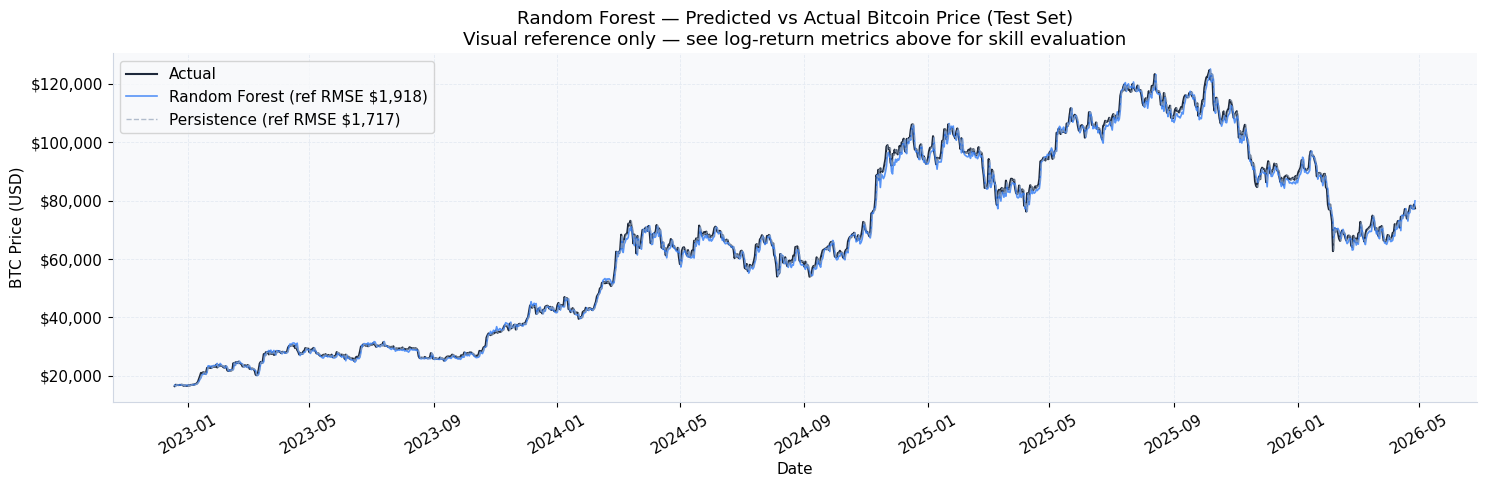

In [9]:
# ── Helpers ────────────────────────────────────────────────────────────────────────────────────
def inv_logret(scaled_pred, close_prev):
    log_ret = scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()
    return close_prev * np.exp(log_ret)

def unscale_logret(scaled_pred):
    return scaler_y.inverse_transform(scaled_pred.reshape(-1, 1)).ravel()

def directional_accuracy(r_true, r_pred):
    return round(float(np.mean(np.sign(r_true) == np.sign(r_pred))) * 100, 2)

# ── RF predictions ────────────────────────────────────────────────────────────────────────────
rf_pred_s = rf_model.predict(X_test_s)
rf_r_pred = unscale_logret(rf_pred_s)
rf_pred   = inv_logret(rf_pred_s, close_prev_test)

# Persistence baseline: log-return = 0  ->  price = close[t-1]
pers_pred  = close_prev_test.copy()
pers_rmse  = float(np.sqrt(np.mean((close_test_actual - pers_pred) ** 2)))

# ── Log-return space metrics (honest skill measure) ────────────────────────────────────
r_true         = y_test.values
rf_logret_rmse = float(np.sqrt(np.mean((r_true - rf_r_pred) ** 2)))
rf_logret_r2   = float(r2_score(r_true, rf_r_pred))
rf_dir_acc     = directional_accuracy(r_true, rf_r_pred)
rf_price_rmse  = float(np.sqrt(np.mean((close_test_actual - rf_pred) ** 2)))

# ── Log metrics to MLflow ──────────────────────────────────────────────────────────────────
try:
    runs = mlflow.search_runs(
        filter_string="tags.`mlflow.runName` = 'rf-btc-usd'",
        order_by=['start_time DESC']
    )
    if not runs.empty:
        with mlflow.start_run(run_id=runs.iloc[0].run_id):
            mlflow.log_metric('logret_rmse',      rf_logret_rmse)
            mlflow.log_metric('logret_r2',        rf_logret_r2)
            mlflow.log_metric('dir_acc',          rf_dir_acc)
            mlflow.log_metric('persistence_rmse', pers_rmse)
except Exception:
    pass

# ── Display honest metrics table ───────────────────────────────────────────────────────────────
metrics_table = pd.DataFrame({
    'Model':            ['Random Forest', 'Persistence'],
    'Log-ret RMSE':     [round(rf_logret_rmse, 5), round(float(np.sqrt(np.mean(r_true**2))), 5)],
    'Log-ret R²':      [round(rf_logret_r2,    4), 0.0],
    'DirAcc %':         [rf_dir_acc,             float('nan')],
    'Price RMSE (ref)': [f'${rf_price_rmse:,.0f}', f'${pers_rmse:,.0f}'],
}).set_index('Model')

display(metrics_table)
print(f'\nRF log-return R²: {rf_logret_r2:.4f}  |  DirAcc: {rf_dir_acc:.1f}%')
print(f'Price RMSE for reference: RF ${rf_price_rmse:,.0f}  vs Persistence ${pers_rmse:,.0f}')

# ── Save artifacts ─────────────────────────────────────────────────────────────────────────────
rf_model_path = os.path.join(MODELS_DIR, 'rf_model.save')
scaler_y_path = os.path.join(MODELS_DIR, 'scaler_y.pkl')
scaler_X_path = os.path.join(MODELS_DIR, 'scaler_X.pkl')

joblib.dump(rf_model, rf_model_path)
joblib.dump(scaler_y, scaler_y_path)
joblib.dump(scaler_X, scaler_X_path)

selection = {
    'model_type':       'rf',
    'model_path':       rf_model_path,
    'logret_rmse':      round(rf_logret_rmse, 5),
    'rmse':             round(rf_price_rmse, 2),      # kept for retrain.py drift detection
    'persistence_rmse': round(pers_rmse, 2),
    'features':         feature_cols,
    'n_estimators':     RF_N_ESTIMATORS,
}
sel_path = os.path.join(MODELS_DIR, 'selection.json')
with open(sel_path, 'w') as f:
    json.dump(selection, f, indent=2)

print(f'\nModel saved      -> {rf_model_path}')
print(f'selection.json   -> {sel_path}')

# ── Predictions visual (reference only) ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dates_test.values, close_test_actual, color=PALETTE['actual'], lw=1.5, label='Actual')
ax.plot(dates_test.values, rf_pred,           color=PALETTE['rf'],    lw=1.2, alpha=0.85,
        label=f'Random Forest (ref RMSE ${rf_price_rmse:,.0f})')
ax.plot(dates_test.values, pers_pred,         color=PALETTE['pers'],  lw=1,   alpha=0.7,
        label=f'Persistence (ref RMSE ${pers_rmse:,.0f})', linestyle='--')
ax.set_title(
    'Random Forest — Predicted vs Actual Bitcoin Price (Test Set)\n'
    'Visual reference only — see log-return metrics above for skill evaluation'
)
ax.set_xlabel('Date')
ax.set_ylabel('BTC Price (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
ax.grid(True)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


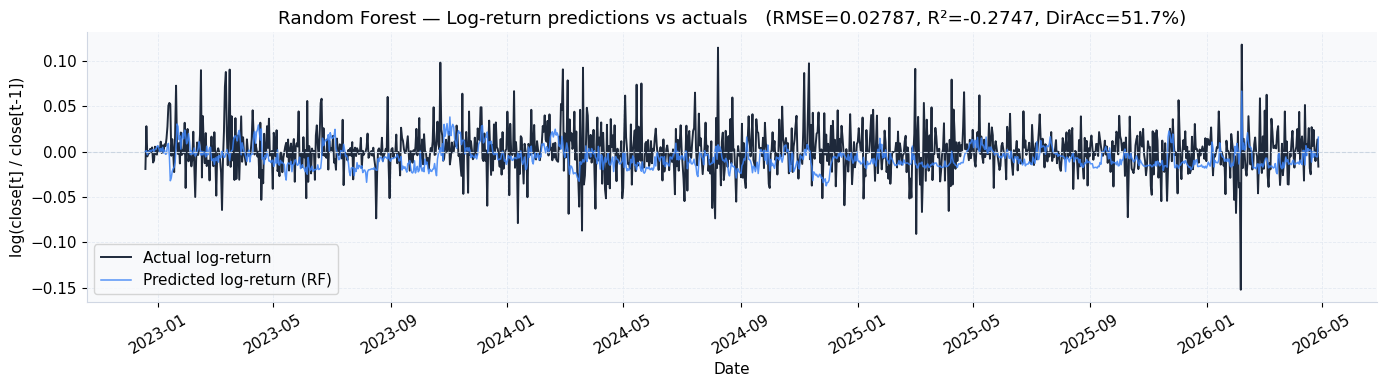

In [10]:
# ── Log-return predictions (what the model actually outputs) ────────────────────────────
# The model predicts log-returns (small values near 0).
# This plot shows predicted vs actual log-returns directly.

actual_log_rets = y_test.values

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_test.values, actual_log_rets, color=PALETTE['actual'], lw=1.4, label='Actual log-return')
ax.plot(dates_test.values, rf_r_pred,       color=PALETTE['rf'],    lw=1.1, alpha=0.85, label='Predicted log-return (RF)')
ax.axhline(0, color='#CBD5E1', lw=0.8, linestyle='--')
ax.set_title(
    f'Random Forest — Log-return predictions vs actuals   '
    f'(RMSE={rf_logret_rmse:.5f}, R²={rf_logret_r2:.4f}, DirAcc={rf_dir_acc:.1f}%)'
)
ax.set_xlabel('Date')
ax.set_ylabel('log(close[t] / close[t-1])')
ax.legend()
ax.grid(True)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## Step 5 — MLOps & Deployment Roadmap

### Tier 1 — Version Control ✅ (complete)
- [x] Git repository initialised
- [x] Virtual environment (`venv`) for dependency isolation
- [x] `requirements.txt` committed

### Tier 2 — Experiment Tracking & Cloud Deployment ✅ (complete)
- [x] MLflow experiment tracking — RF run logged under **`bitcoin-price-prediction`**
- [x] Best model artifact saved (`models/rf_model.save`) with `selection.json`
- [x] Deploy on **Oracle Cloud** (`VM.Standard.E2.1.Micro` — Always Free, Frankfurt `eu-frankfurt-1`)
- [x] Build **FastAPI** REST endpoint (`POST /predict` + `GET /predict/latest` → next-day BTC price)
- [x] Automated data pipeline: daily fetch → feature engineering → drift detection → conditional retrain (`src/training/retrain.py`)
- [x] Model monitoring: recent MAE tracked over last 30 days; retraining triggered when MAE > 1.5 × baseline RMSE

### Tier 3 — Containerisation ✅ (complete)
- [x] `Dockerfile` written — packages FastAPI app + RF model artifact
- [x] Docker image pushed to **Docker Hub** (`brunopulheze/btc-predictor:latest`)
- [x] Container deployed on Oracle Cloud VM via `docker run --restart unless-stopped`

### Tier 4 (Advanced) — CI/CD ✅ (complete)
- [x] GitHub Actions workflow (`.github/workflows/retrain.yml`): runs daily at 06:00 UTC → drift check → if retrained: rebuild Docker image → push to Docker Hub → SSH redeploy on Oracle Cloud VM

### Bonus
- [ ] Price-change alerting via email / Telegram bot
- [ ] Monitoring dashboard via **Grafana** or similar
